# 🤖 Notebook 03 — Unconditional DDPM
**Project:** Volatility-Regime-Conditioned DDPM for NIFTY50 Synthetic Returns  
**IIT Mandi Internship · Quant × GenAI**

---
## What this notebook does
Builds and trains the **Baseline Unconditional Denoising Diffusion Probabilistic Model (DDPM)** for our synthetic financial return generation.

### Key Components:
1. **PyTorch Dataset:** Loads the overlapping sliding windows.
2. **Diffusion Process:** Linear noise schedule with 1000 timesteps.
3. **1D U-Net Architecture:** Designed for sequence data (size=64). Uses sinusoidal time embeddings.
4. **EMA (Exponential Moving Average):** Stabilizes model weights for better sampling quality.
5. **Training Loop:** Features Early Stopping (patience=50) to prevent overfitting on this small dataset.
6. **Sampling:** Generates unconditional synthetic return paths.

**Output:** 
- `outputs/checkpoints/uncond_ddpm_ema.pth` (Model weights)
- `outputs/samples/uncond_samples.pt` (Generated synthetic returns)

## Cell 1 — Install & Import Dependencies

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('tqdm')
install('pyyaml')

print('✅ Dependencies ready')

✅ Dependencies ready


In [2]:
import os
import math
import yaml
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import copy

# ── Device Config ─────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\mahes\Downloads\IIT Mandi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Cell 2 — Load Configuration

In [3]:
CONFIG_PATH = os.path.join('..', 'configs', 'config.yaml')
with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
WIN_DIR  = os.path.join(BASE_DIR, 'data', 'windows')
CHK_DIR  = os.path.join(BASE_DIR, 'outputs', 'checkpoints')
SAMP_DIR = os.path.join(BASE_DIR, 'outputs', 'samples')
FIG_DIR  = os.path.join(BASE_DIR, 'outputs', 'figures')
os.makedirs(CHK_DIR, exist_ok=True)
os.makedirs(SAMP_DIR, exist_ok=True)

SEED = cfg['training']['seed']
torch.manual_seed(SEED)
np.random.seed(SEED)

print('✅ Config loaded and folders created')

✅ Config loaded and folders created


## Cell 3 — Dataset and DataLoader
We load `train_windows.pt`. Since this is an *unconditional* DDPM, we only care about the `returns` tensor. We will reserve a portion (10%) for validation to perform Early Stopping.

In [4]:
class NiftyUncondDataset(Dataset):
    def __init__(self, pt_path):
        data = torch.load(pt_path, weights_only=False)
        self.returns = data['returns'] # Shape: (N, 64)

    def __len__(self):
        return len(self.returns)

    def __getitem__(self, idx):
        # For 1D U-Net, PyTorch expects shape (Channels, Length)
        # Our sequences have 1 channel.
        ret = self.returns[idx].unsqueeze(0) # Shape: (1, 64)
        return ret

# Load full training data
train_pt_path = os.path.join(WIN_DIR, 'train_windows.pt')
full_dataset = NiftyUncondDataset(train_pt_path)

# Train/Val Split
val_frac = cfg['training']['val_fraction']
val_size = int(len(full_dataset) * val_frac)
train_size = len(full_dataset) - val_size

train_ds, val_ds = random_split(full_dataset, [train_size, val_size], 
                                generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=cfg['training']['batch_size'], shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg['training']['batch_size'], shuffle=False)

print(f"Total Windows: {len(full_dataset)}")
print(f"Train Size: {train_size} | Val Size: {val_size}")
print(f"Batch Shape: {next(iter(train_loader)).shape}  (Batch, Channels, SeqLen)")

Total Windows: 3553
Train Size: 3198 | Val Size: 355
Batch Shape: torch.Size([64, 1, 64])  (Batch, Channels, SeqLen)


## Cell 4 — DDPM Noise Schedule
Define the linear schedule for betas, alphas, and alpha_bars (cumulative alphas) used in forward diffusion and loss calculation.

In [5]:
class GaussianDiffusion:
    def __init__(self, num_timesteps, beta_start, beta_end, device):
        self.num_timesteps = num_timesteps
        self.device = device
        
        # Linear noise schedule
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        
    def q_sample(self, x_start, t, noise=None):
        """Forward diffusion: add noise to data at timestep t"""
        if noise is None:
            noise = torch.randn_like(x_start)
            
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1)
        
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

ddpm_schedule = GaussianDiffusion(
    num_timesteps=cfg['diffusion']['num_timesteps'],
    beta_start=cfg['diffusion']['beta_start'],
    beta_end=cfg['diffusion']['beta_end'],
    device=device
)
print("✅ DDPM Schedule initialized")

✅ DDPM Schedule initialized


## Cell 5 — 1D U-Net Components
We need custom 1D convolutions since standard image U-Nets use 2D. We will implement Sinusoidal Time Embeddings and 1D ResNet Blocks.

In [6]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
        )
        
        self.block2 = nn.Sequential(
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
        )
        
        if in_channels != out_channels:
            self.res_conv = nn.Conv1d(in_channels, out_channels, 1)
        else:
            self.res_conv = nn.Identity()

    def forward(self, x, time_emb):
        h = self.block1(x)
        
        # Add time embedding
        time_emb = self.mlp(time_emb).unsqueeze(-1)
        h = h + time_emb
        
        h = self.block2(h)
        return h + self.res_conv(x)

class Downsample1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.down = nn.Conv1d(channels, channels, kernel_size=4, stride=2, padding=1)
        
    def forward(self, x):
        return self.down(x)

class Upsample1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.up = nn.ConvTranspose1d(channels, channels, kernel_size=4, stride=2, padding=1)
        
    def forward(self, x):
        return self.up(x)

## Cell 6 — Unconditional 1D U-Net Architecture

In [7]:
class UncondUNet1D(nn.Module):
    def __init__(self, in_channels=1, channels=[64, 128, 256], time_emb_dim=128, num_res_blocks=2, dropout=0.1):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        self.init_conv = nn.Conv1d(in_channels, channels[0], kernel_size=3, padding=1)
        
        # Down
        self.downs = nn.ModuleList()
        in_ch = channels[0]
        for i, out_ch in enumerate(channels):
            is_last = (i == len(channels) - 1)
            for _ in range(num_res_blocks):
                self.downs.append(ResBlock1D(in_ch, out_ch, time_emb_dim, dropout))
                in_ch = out_ch
            if not is_last:
                self.downs.append(Downsample1D(in_ch))

        # Middle
        self.mid1 = ResBlock1D(in_ch, in_ch, time_emb_dim, dropout)
        self.mid2 = ResBlock1D(in_ch, in_ch, time_emb_dim, dropout)

        # Up
        self.ups = nn.ModuleList()
        reversed_channels = list(reversed(channels))
        for i, out_ch in enumerate(reversed_channels):
            is_last = (i == len(channels) - 1)
            for _ in range(num_res_blocks):
                # in_ch*2 because of skip connections
                self.ups.append(ResBlock1D(in_ch + out_ch, out_ch, time_emb_dim, dropout))
                in_ch = out_ch
            if not is_last:
                self.ups.append(Upsample1D(in_ch))

        self.final_conv = nn.Sequential(
            nn.Conv1d(in_ch, in_ch, 3, padding=1),
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv1d(in_ch, in_channels, 1)
        )

    def forward(self, x, time):
        t_emb = self.time_mlp(time)
        x = self.init_conv(x)
        
        h = x
        skips = []
        
        # Down
        for layer in self.downs:
            if isinstance(layer, ResBlock1D):
                h = layer(h, t_emb)
                skips.append(h)
            else:
                h = layer(h)
                
        # Middle
        h = self.mid1(h, t_emb)
        h = self.mid2(h, t_emb)
        
        # Up
        for layer in self.ups:
            if isinstance(layer, ResBlock1D):
                skip = skips.pop()
                h = torch.cat([h, skip], dim=1)
                h = layer(h, t_emb)
            else:
                h = layer(h)
                
        return self.final_conv(h)

model = UncondUNet1D(
    channels=cfg['model']['channels'],
    time_emb_dim=cfg['model']['embed_dim'],
    num_res_blocks=cfg['model']['num_res_blocks'],
    dropout=cfg['model']['dropout']
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 4,577,985


## Cell 7 — Exponential Moving Average (EMA)
EMA keeps a smoothed version of the model weights. Sampling from the EMA model generally produces much higher quality and stable results.

In [8]:
class EMA:
    def __init__(self, beta):
        super().__init__()
        self.beta = beta
        self.step = 0

    def update_model_average(self, ma_model, current_model):
        for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
            old_weight, up_weight = ma_params.data, current_params.data
            ma_params.data = self.update_average(old_weight, up_weight)

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

    def step_ema(self, ema_model, model):
        self.step += 1
        self.update_model_average(ema_model, model)

ema_model = copy.deepcopy(model).eval().requires_grad_(False)
ema = EMA(beta=cfg['training']['ema_decay'])

## Cell 8 — Training Setup (Loss, Optimizer, Early Stopping)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=cfg['training']['lr'])
criterion = nn.MSELoss()

MAX_EPOCHS = cfg['training']['max_epochs']
PATIENCE = cfg['training']['early_stop_patience']

def calc_loss(model, batch_x):
    # Sample random timesteps
    t = torch.randint(0, ddpm_schedule.num_timesteps, (batch_x.shape[0],), device=device).long()
    # Generate pure noise
    noise = torch.randn_like(batch_x)
    # Diffuse data to timestep t
    x_noisy = ddpm_schedule.q_sample(batch_x, t, noise)
    # Predict noise
    predicted_noise = model(x_noisy, t)
    # Calculate MSE Loss
    loss = criterion(predicted_noise, noise)
    return loss

## Cell 9 — Training Loop

In [10]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience_counter = 0

print("🚀 Starting Unconditional DDPM Training...")
for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_train_loss = 0.0
    
    for batch in train_loader:
        batch = batch.to(device)
        
        optimizer.zero_grad()
        loss = calc_loss(model, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['training']['grad_clip_max_norm'])
        optimizer.step()
        
        ema.step_ema(ema_model, model)
        
        epoch_train_loss += loss.item()
        
    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)
    
    # Validation Loop
    ema_model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for val_batch in val_loader:
            val_batch = val_batch.to(device)
            loss = calc_loss(ema_model, val_batch)
            epoch_val_loss += loss.item()
            
    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)
    
    # Logging & Early Stopping
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:04d} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")
        
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Save best EMA model
        torch.save(ema_model.state_dict(), os.path.join(CHK_DIR, 'uncond_ddpm_ema_best.pth'))
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch}. Best Val Loss: {best_val_loss:.6f}")
        break

print("✅ Training Complete.")

🚀 Starting Unconditional DDPM Training...
Epoch 0001 | Train Loss: 0.342534 | Val Loss: 0.936149
Epoch 0005 | Train Loss: 0.240327 | Val Loss: 0.460354
Epoch 0010 | Train Loss: 0.225900 | Val Loss: 0.317790
Epoch 0015 | Train Loss: 0.243407 | Val Loss: 0.249693
Epoch 0020 | Train Loss: 0.248571 | Val Loss: 0.241848
Epoch 0025 | Train Loss: 0.236994 | Val Loss: 0.253019
Epoch 0030 | Train Loss: 0.223636 | Val Loss: 0.220744
Epoch 0035 | Train Loss: 0.234823 | Val Loss: 0.236844
Epoch 0040 | Train Loss: 0.225572 | Val Loss: 0.270906
Epoch 0045 | Train Loss: 0.230943 | Val Loss: 0.224692
Epoch 0050 | Train Loss: 0.223763 | Val Loss: 0.236027
Epoch 0055 | Train Loss: 0.213051 | Val Loss: 0.213444
Epoch 0060 | Train Loss: 0.209808 | Val Loss: 0.230780
Epoch 0065 | Train Loss: 0.210907 | Val Loss: 0.203583
Epoch 0070 | Train Loss: 0.212775 | Val Loss: 0.201557
Epoch 0075 | Train Loss: 0.201346 | Val Loss: 0.213458
Epoch 0080 | Train Loss: 0.198359 | Val Loss: 0.234315
Epoch 0085 | Train Loss

## Cell 10 — Plot Learning Curves

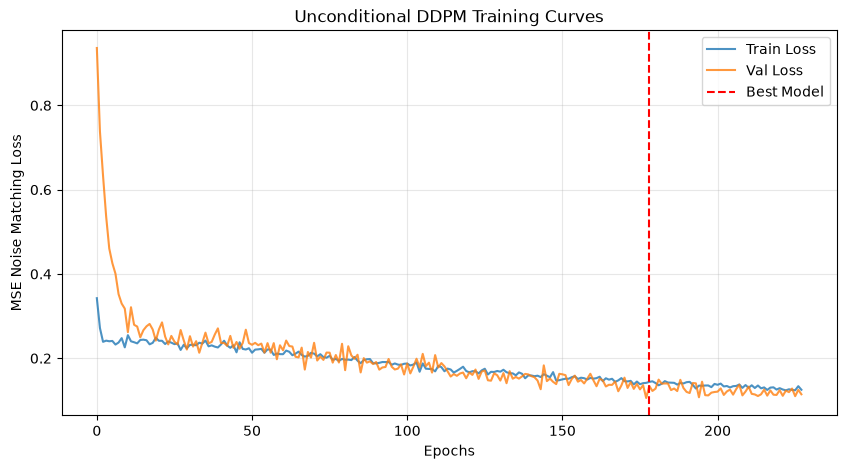

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', alpha=0.8)
plt.plot(val_losses, label='Val Loss', alpha=0.8)
plt.axvline(len(train_losses) - patience_counter, color='r', linestyle='--', label='Best Model')
plt.title('Unconditional DDPM Training Curves')
plt.xlabel('Epochs')
plt.ylabel('MSE Noise Matching Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIG_DIR, 'nb03_uncond_loss.png'), dpi=150)
plt.show()

## Cell 11 — Sampling Generation (Reverse Process)
Now we generate synthetic samples using the trained `ema_model`. The generated samples are de-normalized in the evaluation notebook.

In [12]:
@torch.no_grad()
def p_sample_loop(model, shape):
    model.eval()
    b = shape[0]
    # Start from pure noise
    img = torch.randn(shape, device=device)
    
    for i in tqdm(reversed(range(0, ddpm_schedule.num_timesteps)), desc='Sampling', total=ddpm_schedule.num_timesteps):
        time = torch.full((b,), i, device=device, dtype=torch.long)
        
        # Predict noise
        predicted_noise = model(img, time)
        
        alpha = ddpm_schedule.alphas[i]
        alpha_cumprod = ddpm_schedule.alphas_cumprod[i]
        beta = ddpm_schedule.betas[i]
        
        if i > 0:
            noise = torch.randn_like(img)
        else:
            noise = torch.zeros_like(img)
            
        # Reverse formula
        img = 1 / torch.sqrt(alpha) * (img - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * predicted_noise) + torch.sqrt(beta) * noise
        
    return img

# Load best model weights
ema_model.load_state_dict(torch.load(os.path.join(CHK_DIR, 'uncond_ddpm_ema_best.pth')))

NUM_SAMPLES = cfg['sampling']['num_samples']
SEQ_LEN = cfg['data']['window_size']

print(f"Generating {NUM_SAMPLES} unconditional synthetic paths of length {SEQ_LEN}...")
synthetic_uncond = p_sample_loop(ema_model, shape=(NUM_SAMPLES, 1, SEQ_LEN))
synthetic_uncond = synthetic_uncond.squeeze(1).cpu() # Shape: (N, 64)

torch.save(synthetic_uncond, os.path.join(SAMP_DIR, 'uncond_samples.pt'))
print(f"✅ Saved synthetic returns to {SAMP_DIR}/uncond_samples.pt")

Generating 500 unconditional synthetic paths of length 64...


Sampling: 100%|██████████| 1000/1000 [08:03<00:00,  2.07it/s]

✅ Saved synthetic returns to c:\Users\mahes\Downloads\IIT Mandi\nifty-ddpm\outputs\samples/uncond_samples.pt


## Cell 12 — Visualizing Synthetic Samples vs Real Samples

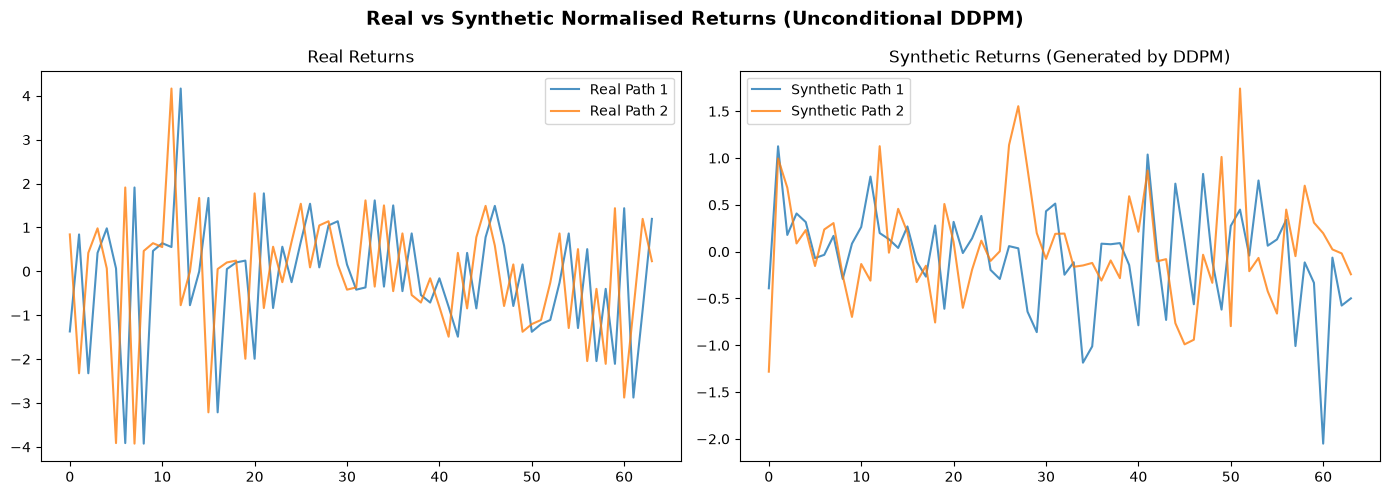

In [13]:
# Load some real train samples for visual comparison
real_returns = full_dataset.returns[:NUM_SAMPLES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Real vs Synthetic Normalised Returns (Unconditional DDPM)', fontsize=14, fontweight='bold')

# Real
axes[0].plot(real_returns[0].numpy(), label='Real Path 1', alpha=0.8)
axes[0].plot(real_returns[1].numpy(), label='Real Path 2', alpha=0.8)
axes[0].set_title('Real Returns')
axes[0].legend()

# Synthetic
axes[1].plot(synthetic_uncond[0].numpy(), label='Synthetic Path 1', alpha=0.8)
axes[1].plot(synthetic_uncond[1].numpy(), label='Synthetic Path 2', alpha=0.8)
axes[1].set_title('Synthetic Returns (Generated by DDPM)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb03_real_vs_synthetic.png'), dpi=150)
plt.show()

## ✅ Notebook 03 Complete

### What was achieved:
We successfully built and trained a 1D Unconditional DDPM, applied Early Stopping with a validation set to prevent overfitting, updated an EMA model for stability, and generated purely synthetic log return paths.

### Next Step
→ **Notebook 04** (`04_conditional_ddpm.ipynb`) — Adding Volatility Regime Conditioning via FiLM to the DDPM.